## SALARY GAP ANALYSIS

- The analysis aims to find insights on the impact of several factors like experience level, company size, work models, job title etc on the salary. 
- In addition to this, I will also be trying to predict the salary based on other factors based on which ones correlate the most.

#### Importing the libraries needed

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

#### Reading the csv file into a dataframe object and viewing basic stats

In [19]:
salary = pd.read_csv('data_science_salaries.csv')

In [20]:
print(salary.head()) # preview the data
print(salary.describe)

        job_title experience_level employment_type work_models  work_year  \
0   Data Engineer        Mid-level       Full-time      Remote       2024   
1   Data Engineer        Mid-level       Full-time      Remote       2024   
2  Data Scientist     Senior-level       Full-time      Remote       2024   
3  Data Scientist     Senior-level       Full-time      Remote       2024   
4    BI Developer        Mid-level       Full-time     On-site       2024   

  employee_residence  salary salary_currency  salary_in_usd company_location  \
0      United States  148100             USD         148100    United States   
1      United States   98700             USD          98700    United States   
2      United States  140032             USD         140032    United States   
3      United States  100022             USD         100022    United States   
4      United States  120000             USD         120000    United States   

  company_size  
0       Medium  
1       Medium  
2    

### Data cleaning

Here are the data cleaning steps that I am going to perform:
- Renaming the salary_in_usd column as salary and salry column as salary_in_country as we will be using the usd salary equivalents to maintain consistency in our analysis
- Check for missing values in the salary(usd) column and remove them.
- Check for unique values in experience_level and encode them to numerical levels to perform further statistical analysis

In [21]:
# Rename salary_in_usd column and salary column to salary_in_country
salary = salary.rename(columns={'salary':'salary_in_country','salary_in_usd':'salary'})
salary = salary.rename(columns={'salary_in_usd':'salary'})
# Check for missing values in columns
print(salary.isna().sum())
# Checking unique values in salary_curreny column
print(salary['salary_currency'].unique())
# Check for unique values in experience_level and encode them to numerical levels
print(salary['experience_level'].unique())
# Dictionary to map numerical values
# Dictionary for mapping experience levels to numerical values
experience_map = {
    'Entry-level': 0,
    'Mid-level': 1,
    'Senior-level': 2,
    'Executive-level': 3
}
# Create the new column with the mapped values
salary['experience_level_encoded'] = salary['experience_level'].map(experience_map)
print(salary['experience_level_encoded'].unique())

job_title             0
experience_level      0
employment_type       0
work_models           0
work_year             0
employee_residence    0
salary_in_country     0
salary_currency       0
salary                0
company_location      0
company_size          0
dtype: int64
['USD' 'GBP' 'EUR' 'TRY' 'THB' 'ZAR' 'SGD' 'INR' 'PLN' 'PHP' 'NOK' 'ILS'
 'HKD' 'AUD' 'CHF' 'CAD' 'BRL' 'JPY' 'HUF' 'DKK' 'CLP' 'MXN']
['Mid-level' 'Senior-level' 'Entry-level' 'Executive-level']
[1 2 0 3]


In [13]:
# Checking unique values in Job titles
print(salary['job_title'].unique())

['Data Engineer' 'Data Scientist' 'BI Developer' 'Research Analyst'
 'Business Intelligence Developer' 'Data Analyst'
 'Director of Data Science' 'MLOps Engineer' 'Machine Learning Scientist'
 'Machine Learning Engineer' 'Data Science Manager' 'Applied Scientist'
 'Business Intelligence Analyst' 'Analytics Engineer'
 'Business Intelligence Engineer' 'Data Science' 'Research Scientist'
 'Research Engineer' 'Managing Director Data Science' 'AI Engineer'
 'Data Specialist' 'Data Architect' 'Data Visualization Specialist'
 'ETL Developer' 'Data Science Practitioner' 'Computer Vision Engineer'
 'Data Lead' 'ML Engineer' 'Data Developer' 'Data Modeler'
 'Data Science Consultant' 'AI Architect' 'Data Analytics Manager'
 'Data Science Engineer' 'Data Product Manager' 'Data Quality Analyst'
 'Data Strategist' 'Prompt Engineer' 'Data Science Lead'
 'Business Intelligence Manager' 'Data Manager' 'Data Analytics Lead'
 'Machine Learning Infrastructure Engineer' 'Data Integration Engineer'
 'Data M

##### Standardize the job titles to reduce the number of titles

In [49]:
def standardize_title(x):
    if 'BI' in x or 'Visualization' in x or 'Business Intelligence' in x:
        return('BI developer')
    elif 'Data Engineer' in x or 'ETL' in x:
        return('Data Engineer')
    elif 'Data Scientist' in x or 'Data Science' in x:
        return('Data Scientist')
    elif 'AI' in x:
        return('AI Engineer')
    elif 'ML' in x or 'Machine' in x or 'Deep Learning' in x or 'NLP' in x:
        return('Machine Learning Engineer')
    elif 'Data Analyst' in x or 'Data Analytics' in x:
        return('Data Analyst')
    elif 'Data Architect' in x:
        return('Data Architect')
    elif 'Data Operations' in x:
        return('Data Operations')
    elif 'Management' in x or 'Manager' in x:
        return('Data Manager')
    else:
        return(x)
salary['std_job_title'] = salary['job_title'].apply(standardize_title)
print(salary['std_job_title'].unique())
    

['Data Engineer' 'Data Scientist' 'BI developer' 'Research Analyst'
 'Data Analyst' 'Machine Learning Engineer' 'Applied Scientist'
 'Analytics Engineer' 'Research Scientist' 'Research Engineer'
 'AI Engineer' 'Data Specialist' 'Data Architect'
 'Computer Vision Engineer' 'Data Lead' 'Data Developer' 'Data Modeler'
 'Data Manager' 'Data Quality Analyst' 'Data Strategist' 'Prompt Engineer'
 'Data Integration Engineer' 'Head of Data' 'Data Integration Specialist'
 'Data Quality Engineer' 'Decision Scientist'
 'Data Infrastructure Engineer' 'Data Operations'
 'Cloud Database Engineer' 'Insight Analyst' 'Data Product Owner'
 'Data Modeller' 'Autonomous Vehicle Technician' 'Data DevOps Engineer'
 'Computer Vision Software Engineer']


### Analysis to uncover some insights

In [48]:
# Get top 10 high paying job titles and aplot them
grouped = salary.groupby('std_job_title')['salary'].mean().reset_index()
top_n = grouped.nlargest(10,'salary',keep="all").sort_values(by='salary',ascending=False).reset_index()
print(top_n)
bottom_n = grouped.nsmallest(10,'salary',keep="all").sort_values(by='salary',ascending=True).reset_index()
print(bottom_n)

   index              std_job_title         salary
0      8  Machine Learning Engineer  174970.041280
1      3             Data Architect  163531.823204
2      9                      other  158575.448654
3      7             Data Scientist  151127.358974
4      0                AI Engineer  145929.972727
5      4              Data Engineer  143360.867994
6      5               Data Manager  120282.326087
7      1               BI developer  117476.132653
8      6            Data Operations  115618.214286
9      2               Data Analyst  106668.131213
   index              std_job_title         salary
0      2               Data Analyst  106668.131213
1      6            Data Operations  115618.214286
2      1               BI developer  117476.132653
3      5               Data Manager  120282.326087
4      4              Data Engineer  143360.867994
5      0                AI Engineer  145929.972727
6      7             Data Scientist  151127.358974
7      9                      o

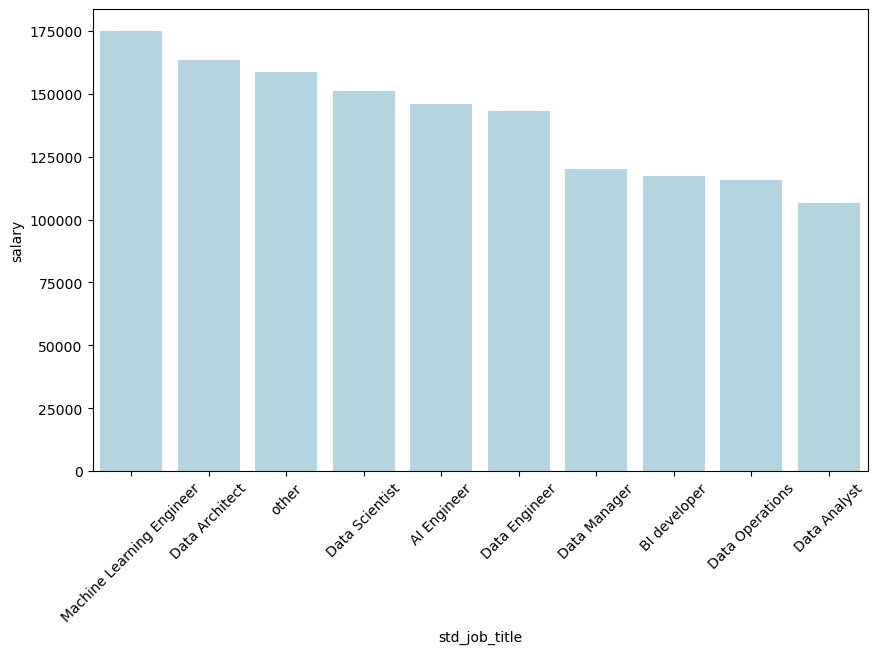

In [58]:
# Salries by job title
plt.figure(figsize=(10, 6))  # Adjust the figure size if needed
sns.barplot(x="std_job_title", y="salary", data=top_n , color='lightblue')

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45)  # You can change the angle as needed (e.g., 45, 90)

# Show the plot
plt.show()

- An ML Engineer, Data scientist, Architects earn more than a BI developer or Data analyst

In [59]:
salary.columns

Index(['job_title', 'experience_level', 'employment_type', 'work_models',
       'work_year', 'employee_residence', 'salary_in_country',
       'salary_currency', 'salary', 'company_location', 'company_size',
       'experience_level_encoded', 'std_job_title'],
      dtype='object')

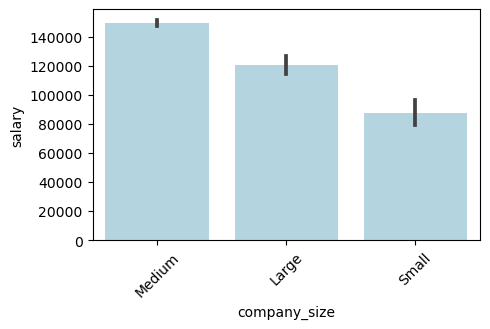

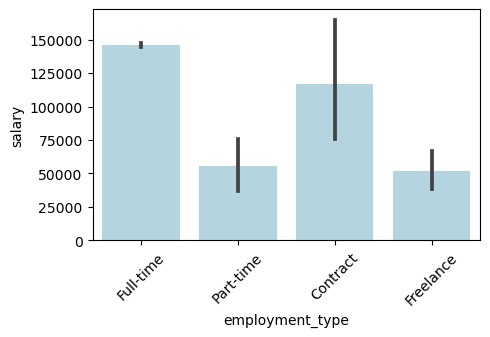

In [63]:
#company size vs salary
plt.figure(figsize=(5, 3))  # Adjust the figure size if needed
sns.barplot(x="company_size", y="salary", data=salary , color='lightblue')

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45)  # You can change the angle as needed (e.g., 45, 90)

# Show the plot
plt.show()
#Employment type vs salary
plt.figure(figsize=(5, 3))  # Adjust the figure size if needed
sns.barplot(x="employment_type", y="salary", data=salary , color='lightblue')

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45)  # You can change the angle as needed (e.g., 45, 90)

# Show the plot
plt.show()



##### Does company size impact salary of a senior level,Mid,executive or Entry level employee?

In [67]:
size_level = salary.groupby(['company_size','experience_level'])['salary'].mean()
print(size_level)

company_size  experience_level
Large         Entry-level          74603.330435
              Executive-level     187993.900000
              Mid-level           100625.171271
              Senior-level        150556.660079
Medium        Entry-level          89223.052369
              Executive-level     190563.402655
              Mid-level           123303.988827
              Senior-level        163532.470666
Small         Entry-level          68485.938776
              Executive-level     169172.375000
              Mid-level            73769.645161
              Senior-level        110273.725490
Name: salary, dtype: float64


- Overall it looks like in general the salaries of all levels of employees are greater in a company that is Medium size. Let us check how they correlate

In [70]:
size_map = {
    'Small': 1,
    'Medium': 2,
    'Large': 3
}
# Create the new column with the mapped values
salary['company_size_encoded'] = salary['company_size'].map(size_map)
salary['company_size_encoded'].corr(salary['salary'], method='pearson')  

-0.028181458243146516

- It doesn't seem like there is a strong correlation between the two
- Let us explore correlation between other factors like experience_level with salary and plot a heatmap

In [73]:
salary['work_models'].unique()

array(['Remote', 'On-site', 'Hybrid'], dtype=object)

In [75]:
model_map = {
    'Remote': 0,
    'Hybrid': 1,
    'On-site': 2
}
# Create the new column with the mapped values
salary['work_models_encoded'] = salary['work_models'].map(model_map)  

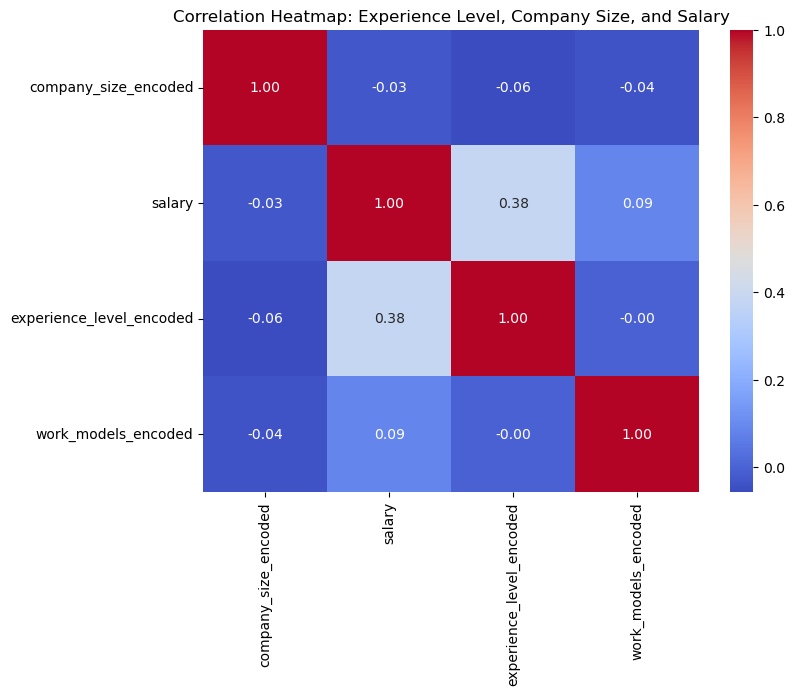

In [76]:
df = salary[['company_size_encoded','salary','experience_level_encoded','work_models_encoded']]
# Calculate correlation matrix
correlation_matrix = df.corr()
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap: Experience Level, Company Size, and Salary')
plt.show()

- There seems to be some correlation between salary and experience level which is natural.

In [77]:
salary.groupby(['work_models'])['salary'].mean()

work_models
Hybrid      83293.502222
On-site    152600.100970
Remote     140550.137837
Name: salary, dtype: float64

- Even though there is no correlation between work_model and the salary, it does look like On-site workers are paid slightly more on an average compared to Remote workers and way more than Hybrid workers.

##### We also want to take a look at how much the salaries have grown year-wise

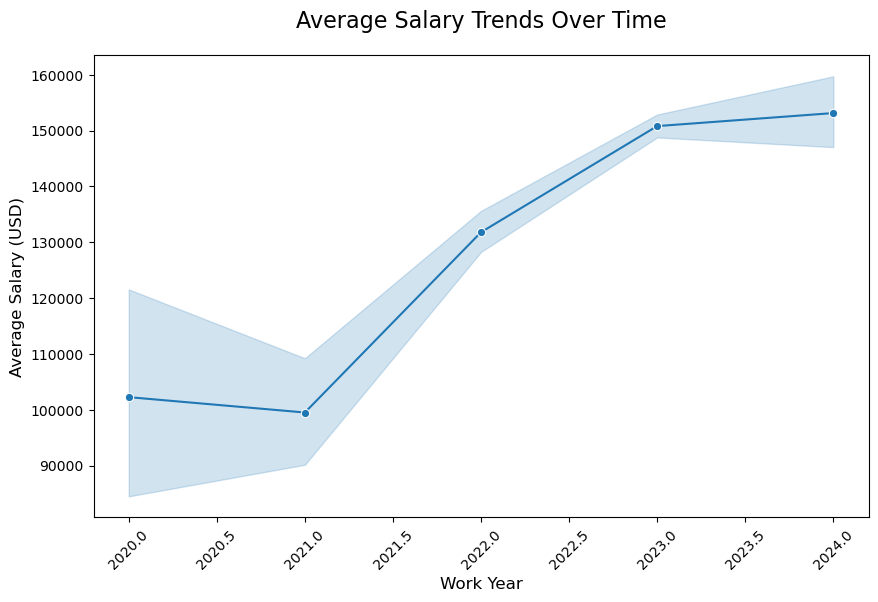

In [82]:
# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    x="work_year", 
    y="salary", 
    data=salary, 
    marker="o",  # Adds markers at data points
)

# Customize labels and title
plt.title("Average Salary Trends Over Time", fontsize=16, pad=20)
plt.xlabel("Work Year", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels if years are crowded

# Show plot
plt.show()

- Looks like there was a dip in 2021 apart from which the salaries overall has been on the rise which means the demand for data jobs are more every year.

In [137]:
salary.loc[salary['salary'].idxmax()]

job_title                   Machine Learning Scientist
experience_level                             Mid-level
employment_type                              Full-time
work_models                                    On-site
work_year                                         2024
employee_residence                       United States
salary_in_country                               750000
salary_currency                                    USD
salary                                          750000
company_location                         United States
company_size                                    Medium
experience_level_encoded                             1
std_job_title                Machine Learning Engineer
company_size_encoded                                 2
work_models_encoded                                  2
Name: 296, dtype: object

In [131]:
location_grouped = salary.groupby(['company_location'])['salary'].mean().reset_index()
Top_locations = location_grouped.sort_values(by='salary',ascending=False).head(15).reset_index(drop=True)
Bottom_locations = location_grouped.sort_values(by='salary',ascending=True).head(15).reset_index(drop=True)
display(Top_locations)
display(Bottom_locations)

,company_location,salary
0,Qatar,300000.000000
1,Israel,217332.000000
2,Puerto Rico,167500.000000
3,United States,157073.099365
4,New Zealand,151634.333333
5,Canada,139832.753086
6,Saudi Arabia,134999.000000
7,Ukraine,121333.333333
8,Bosnia and Herzegovina,120000.000000
9,Australia,114673.406250


,company_location,salary
0,Ecuador,16000.000000
1,Moldova,18000.000000
2,Honduras,20000.000000
3,Turkey,22313.600000
4,Thailand,22971.333333
5,Ghana,27000.000000
6,Malta,28369.000000
7,Pakistan,30000.000000
8,Hungary,32139.666667
9,Indonesia,34208.000000


#### Predictive Modeling 

- We see that the experience level and the company size somewhat impact the salary. 
- Let us use regression with these two variables as predictors to predict the salary


In [100]:
salary.columns

Index(['job_title', 'experience_level', 'employment_type', 'work_models',
       'work_year', 'employee_residence', 'salary_in_country',
       'salary_currency', 'salary', 'company_location', 'company_size',
       'experience_level_encoded', 'std_job_title', 'company_size_encoded',
       'work_models_encoded'],
      dtype='object')

In [83]:
import scipy.linalg

In [103]:
# Constructing X matrix with just two predictors namely company_size_encode and experience_level_encoded
X = df[['company_size_encoded', 'experience_level_encoded','work_models_encoded']]

# Convert to numpy array (optional)
X = X.values
X = np.column_stack([np.ones(len(X)), X])  # Add intercept column  
# Constructiong vector of y-values with salary
y = np.array(df['salary'])

In [105]:
X

array([[1., 2., 1., 0.],
       [1., 2., 1., 0.],
       [1., 2., 2., 0.],
       ...,
       [1., 3., 2., 1.],
       [1., 3., 1., 1.],
       [1., 1., 2., 2.]])

In [104]:
# QR decomposition of X
Q, R = np.linalg.qr(X)
from scipy.linalg import solve_triangular
#Use  formula Rtheta = Q.Ty
b = Q.T.dot(y)
theta = solve_triangular(R, b)
print(theta)

[76344.50634992  -712.52921366 38960.52512391  6576.52239469]


- -712.52921366, 38960.52512391 and 6576.52239469 are the coeffcients computed for our Linear regression model for company size and experience level and work models respectively
- The coeficient of experience level is larger indicating that it is an important factor in determining salary

In [117]:
print(salary['company_size_encoded'].unique())
print(salary['experience_level'].unique())
print(salary['work_models_encoded'].unique())

[2 3 1]
['Mid-level' 'Senior-level' 'Entry-level' 'Executive-level']
[0 2 1]


#### Example prediction

In [116]:
def predict_salary(company_size, experience, work_model):
    theta = [76344.50634992 , -712.52921366, 38960.52512391,  6576.52239469]  # [Intercept, theta1,2,3]  
    return theta[0] + theta[1] * company_size + theta[2] * experience + theta[3] * work_model  

# Example prediction: Medium company (2), Mid-level (1), Hybrid (1)  
print(predict_salary(2, 1, 1)) 


120456.49544120001
